# EBT Film Analysis for CCB Dataset

This notebook processes TIFF files from EBT film scans acquired at CCB and converts them to dose distributions.

In [ ]:
# Imports
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile

# Add src to path
project_root = Path.cwd().parents[2]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

# Import our modules
from ebt import (
    ebt3_proton_calib_20Gy,
    ebt3_dose_Gy,
    get_tiff_dpi,
    get_px_to_mm,
    FilePairData,
    get_red_channel,
    auto_crop_dose,
    rotate_dose
)
from visualise.dose import (
    create_dose_colormap,
    plot_raw_signal_comparison,
    plot_dose_with_background
)

print(f'Calibration: {ebt3_proton_calib_20Gy}')

Calibration: f(x) = 7.94*x + 21.39*x^2 + 70.33*x^3


## Configuration

In [63]:
# Data directory
DATA_DIR = Path(r'C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\ebt_ccb')
print(f'Data directory exists: {DATA_DIR.exists()}')
print(f'Data directory: {DATA_DIR}')

# File pairs: signal file -> background file
# Each pair is (signal_path_relative_to_DATA_DIR, background_path_relative_to_DATA_DIR)
FILE_PAIRS = [
    (r"szyba1_150dpi\gaf1_pik_Bragga_CCB_SZYBA1057.tif", r"szyba1_150dpi\gaf1-2_Sadel_20251209_SZYBA1_030.tif"),
    (r"szyba1_72dpi\gaf1_pik_Bragga_CCB_SZYBA1058.tif", r"szyba1_72dpi\gaf1-2_Sadel_20251209_SZYBA1_031.tif"),
    (r"bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif", r"bez_szyby_150dpi\gaf1-2_Sadel_20251209_029.tif"),
]

# Cropping parameters
CROP_DOSE_THRESHOLD_GY = 2.0
CROP_SMOOTH_SIGMA_MM = 0.2
CROP_MIN_DIAMETER_MM = 10.0
CROP_MARGIN_MM = 1.0

# Colormap parameters
CMAP_WHITE_THRESHOLD_PERCENT = 1.0

Data directory exists: True
Data directory: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\ebt_ccb


## Process File Pairs

In [64]:
# Process each file pair
processed_pairs = {}

for signal_rel, bg_rel in FILE_PAIRS:
    signal_path = DATA_DIR / signal_rel
    bg_path = DATA_DIR / bg_rel
    
    print(f'\n{"="*60}')
    print(f'Processing pair:')
    print(f'  Signal: {signal_rel}')
    print(f'  Background: {bg_rel}')
    print(f'{"="*60}')
    
    # Read signal file
    signal_dpi = get_tiff_dpi(signal_path)
    signal_px_to_mm = get_px_to_mm(signal_dpi)
    signal_raw = tifffile.imread(signal_path)
    print(f'Signal: DPI={signal_dpi:.1f}, shape={signal_raw.shape}')
    
    # Read background file
    bg_dpi = get_tiff_dpi(bg_path)
    bg_raw = tifffile.imread(bg_path)
    print(f'Background: DPI={bg_dpi:.1f}, shape={bg_raw.shape}')
    
    # Verify matching DPI
    if abs(signal_dpi - bg_dpi) > 1:
        print(f'WARNING: DPI mismatch! Signal={signal_dpi}, Background={bg_dpi}')
    
    # Convert to dose
    dose_signal = ebt3_dose_Gy(signal_raw)
    dose_bg = ebt3_dose_Gy(bg_raw)
    print(f'Signal dose range: [{dose_signal.min():.2f}, {dose_signal.max():.2f}] Gy')
    print(f'Background dose range: [{dose_bg.min():.2f}, {dose_bg.max():.2f}] Gy')
    
    # Store using FilePairData
    pair_data = FilePairData(
        signal_path=signal_path,
        background_path=bg_path,
        dpi=signal_dpi,
        px_to_mm=signal_px_to_mm,
        signal_raw=signal_raw,
        background_raw=bg_raw,
        dose_full=dose_signal,
        background_dose_full=dose_bg,
        shape=signal_raw.shape
    )
    
    # Use parent folder name as key (unique identifier)
    key = signal_path.parent.name
    processed_pairs[key] = pair_data

print(f'\n{"="*60}')
print(f'Total pairs processed: {len(processed_pairs)}')
print(f'{"="*60}')
for key, pair_data in processed_pairs.items():
    print(f'  {key}: {pair_data}')


Processing pair:
  Signal: szyba1_150dpi\gaf1_pik_Bragga_CCB_SZYBA1057.tif
  Background: szyba1_150dpi\gaf1-2_Sadel_20251209_SZYBA1_030.tif
Signal: DPI=150.0, shape=(1500, 1200, 3)
Background: DPI=150.0, shape=(1500, 1200, 3)
Signal dose range: [-1.18, 117.93] Gy
Background dose range: [-1.18, 119.50] Gy

Processing pair:
  Signal: szyba1_72dpi\gaf1_pik_Bragga_CCB_SZYBA1058.tif
  Background: szyba1_72dpi\gaf1-2_Sadel_20251209_SZYBA1_031.tif
Signal: DPI=72.0, shape=(720, 576, 3)
Background: DPI=72.0, shape=(720, 576, 3)
Signal dose range: [-1.18, 84.23] Gy
Background dose range: [-1.18, 89.50] Gy

Processing pair:
  Signal: bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif
  Background: bez_szyby_150dpi\gaf1-2_Sadel_20251209_029.tif
Signal: DPI=150.0, shape=(1500, 1200, 3)
Background: DPI=150.0, shape=(1500, 1200, 3)
Signal dose range: [-1.18, 120.75] Gy
Background dose range: [-1.18, 120.75] Gy

Total pairs processed: 3
  szyba1_150dpi: FilePairData(signal='gaf1_pik_Bragga_CCB_SZYBA1057.ti

## Visualize First Pair

In [65]:
# Select the first pair to visualize
if processed_pairs:
    pair_key = list(processed_pairs.keys())[2]
    pair_data = processed_pairs[pair_key]
    print(f'Visualizing pair: {pair_key}')
    print(f'  Signal: {pair_data.signal_path.relative_to(DATA_DIR)}')
    print(f'  Background: {pair_data.background_path.relative_to(DATA_DIR)}')
else:
    print('No pairs processed yet')
    pair_data = None

Visualizing pair: bez_szyby_150dpi
  Signal: bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif
  Background: bez_szyby_150dpi\gaf1-2_Sadel_20251209_029.tif


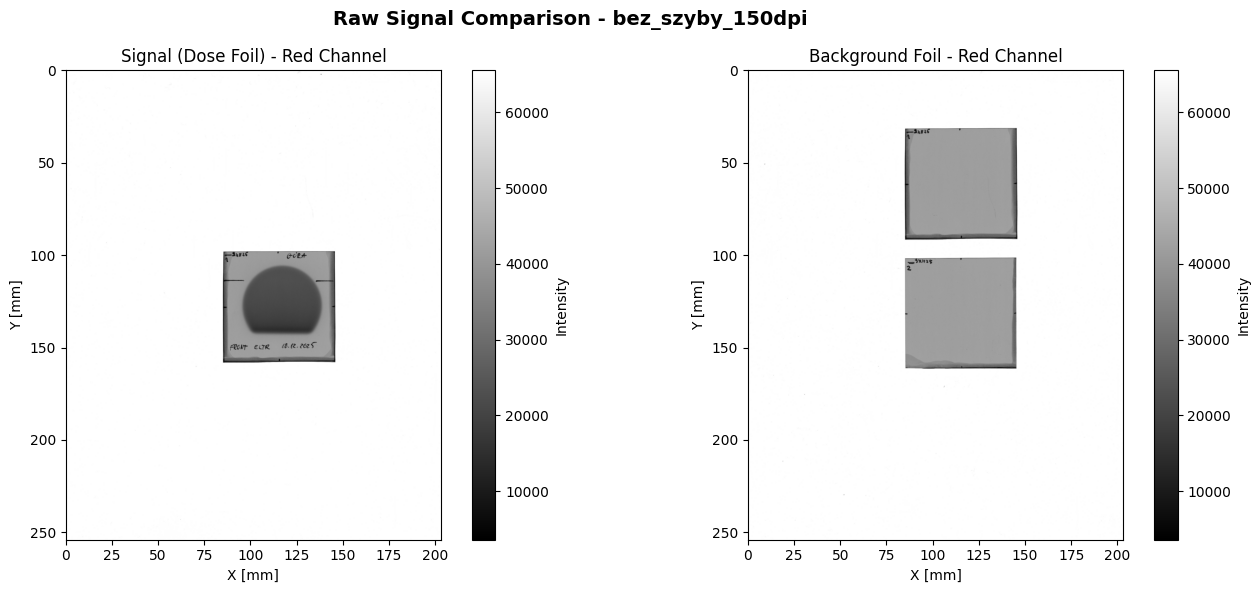

In [66]:
# Plot raw signal comparison (signal vs background)
if pair_data:
    signal_red = get_red_channel(pair_data.signal_raw)
    bg_red = get_red_channel(pair_data.background_raw)
    
    fig = plot_raw_signal_comparison(
        signal_image=signal_red,
        background_image=bg_red,
        px_to_mm=pair_data.px_to_mm,
        title=f'Raw Signal Comparison - {pair_key}'
    )
    plt.show()

## Dose Comparison (Signal vs Background)

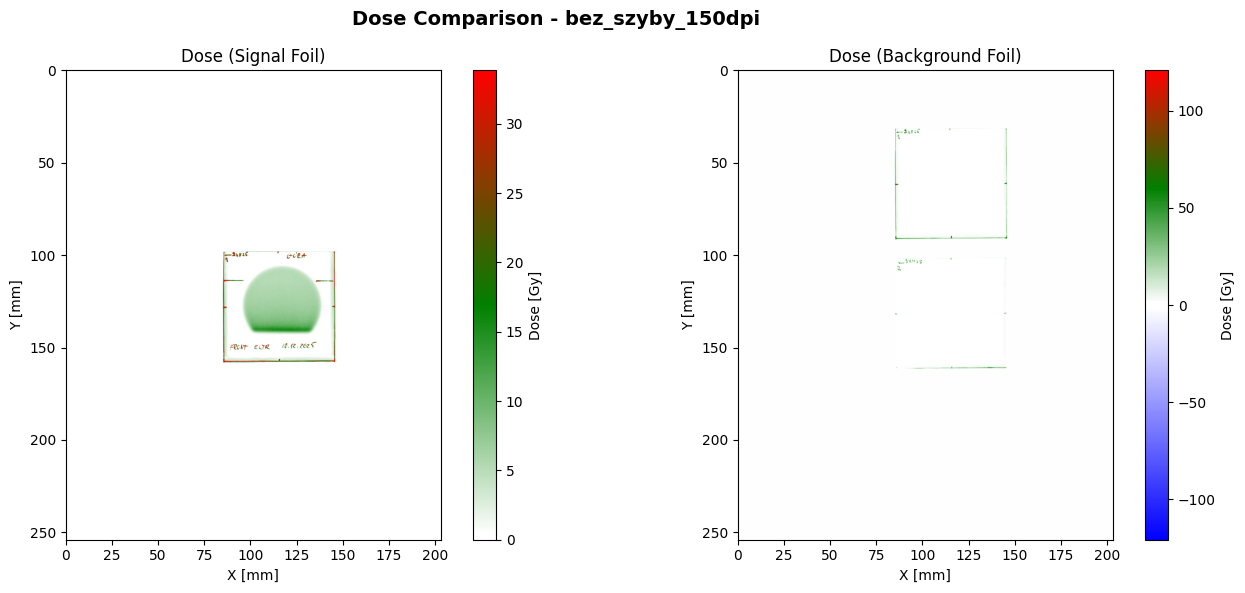

In [67]:
# Plot dose comparison (signal dose vs background dose)
if pair_data:
    fig = plot_dose_with_background(
        dose_array=pair_data.dose_full,
        background_dose_array=pair_data.background_dose_full,
        px_to_mm=pair_data.px_to_mm,
        title=f'Dose Comparison - {pair_key}',
        white_threshold_percent=CMAP_WHITE_THRESHOLD_PERCENT
    )
    plt.show()

## Crop First Pair (using signal foil bounding box)

In [68]:
# Crop the first pair using signal foil's bounding box
if pair_data:
    px_to_mm = pair_data.px_to_mm
    
    # Auto-crop signal dose to find ROI
    dose_cropped, bbox = auto_crop_dose(
        pair_data.dose_full,
        px_to_mm=px_to_mm,
        dose_threshold_gy=CROP_DOSE_THRESHOLD_GY,
        smooth_sigma_mm=CROP_SMOOTH_SIGMA_MM,
        min_diameter_mm=CROP_MIN_DIAMETER_MM,
        margin_mm=CROP_MARGIN_MM,
    )
    
    print(f'Crop bbox from signal foil: Y[{bbox[0]}:{bbox[1]}], X[{bbox[2]}:{bbox[3]}]')
    
    # Apply same crop to all arrays
    y_start, y_end, x_start, x_end = bbox
    
    # Crop signal raw (red channel)
    signal_red = get_red_channel(pair_data.signal_raw)
    signal_raw_cropped = signal_red[y_start:y_end, x_start:x_end]
    
    # Crop background raw - use same bbox if shapes match
    bg_red = get_red_channel(pair_data.background_raw)
    if pair_data.background_raw.shape == pair_data.signal_raw.shape:
        bg_raw_cropped = bg_red[y_start:y_end, x_start:x_end]
    else:
        print('WARNING: Background shape differs from signal, using full background')
        bg_raw_cropped = bg_red
    
    # Crop background dose
    if pair_data.background_dose_full.shape == pair_data.dose_full.shape:
        bg_dose_cropped = pair_data.background_dose_full[y_start:y_end, x_start:x_end]
    else:
        bg_dose_cropped = pair_data.background_dose_full
    
    # Rotate all arrays 90 degrees anti-clockwise
    dose_cropped = rotate_dose(dose_cropped, k=1)
    signal_raw_cropped = rotate_dose(signal_raw_cropped, k=1)
    bg_raw_cropped = rotate_dose(bg_raw_cropped, k=1)
    bg_dose_cropped = rotate_dose(bg_dose_cropped, k=1)
    
    print(f'Cropped shape after rotation: {dose_cropped.shape}')
    
    # Store cropped data in pair_data
    pair_data.dose_cropped = dose_cropped
    pair_data.signal_cropped = signal_raw_cropped
    pair_data.background_cropped = bg_raw_cropped
    pair_data.background_dose_cropped = bg_dose_cropped
    pair_data.crop_bbox = bbox

Crop bbox from signal foil: Y[620:848], X[558:820]
Cropped shape after rotation: (262, 228)


## Cropped Raw Signal Comparison

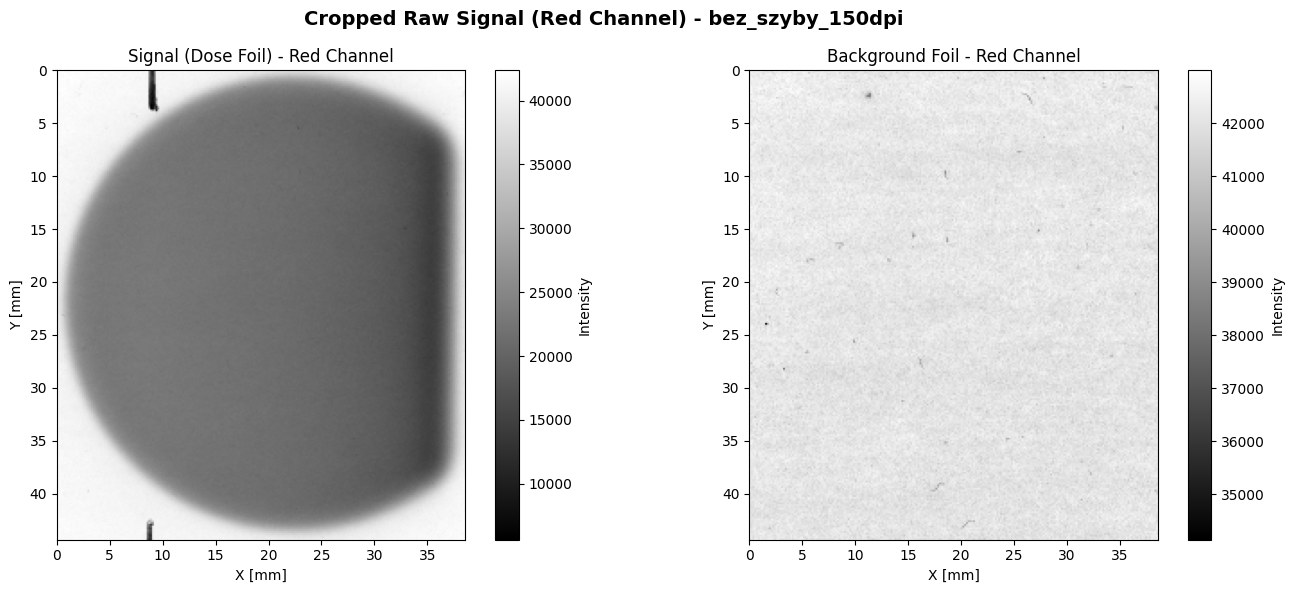

In [69]:
# Plot cropped raw signal comparison (signal vs background)
if pair_data and pair_data.signal_cropped is not None:
    fig = plot_raw_signal_comparison(
        signal_image=pair_data.signal_cropped,
        background_image=pair_data.background_cropped,
        px_to_mm=pair_data.px_to_mm,
        title=f'Cropped Raw Signal (Red Channel) - {pair_key}'
    )
    plt.show()

## Cropped Dose Comparison

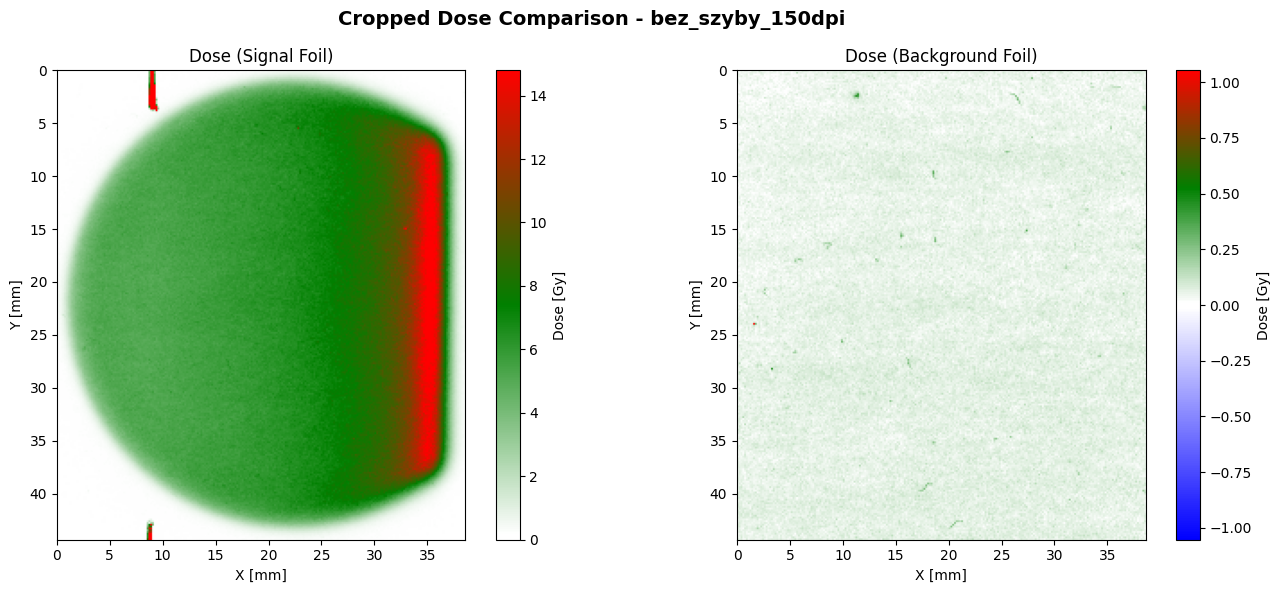

In [70]:
# Plot cropped dose comparison (signal dose vs background dose)
if pair_data and pair_data.dose_cropped is not None:
    fig = plot_dose_with_background(
        dose_array=pair_data.dose_cropped,
        background_dose_array=pair_data.background_dose_cropped,
        px_to_mm=pair_data.px_to_mm,
        title=f'Cropped Dose Comparison - {pair_key}',
        white_threshold_percent=CMAP_WHITE_THRESHOLD_PERCENT
    )
    plt.show()

## Process and Visualize All Pairs


Pair: szyba1_150dpi
  Signal: gaf1_pik_Bragga_CCB_SZYBA1057.tif
  Background: gaf1-2_Sadel_20251209_SZYBA1_030.tif



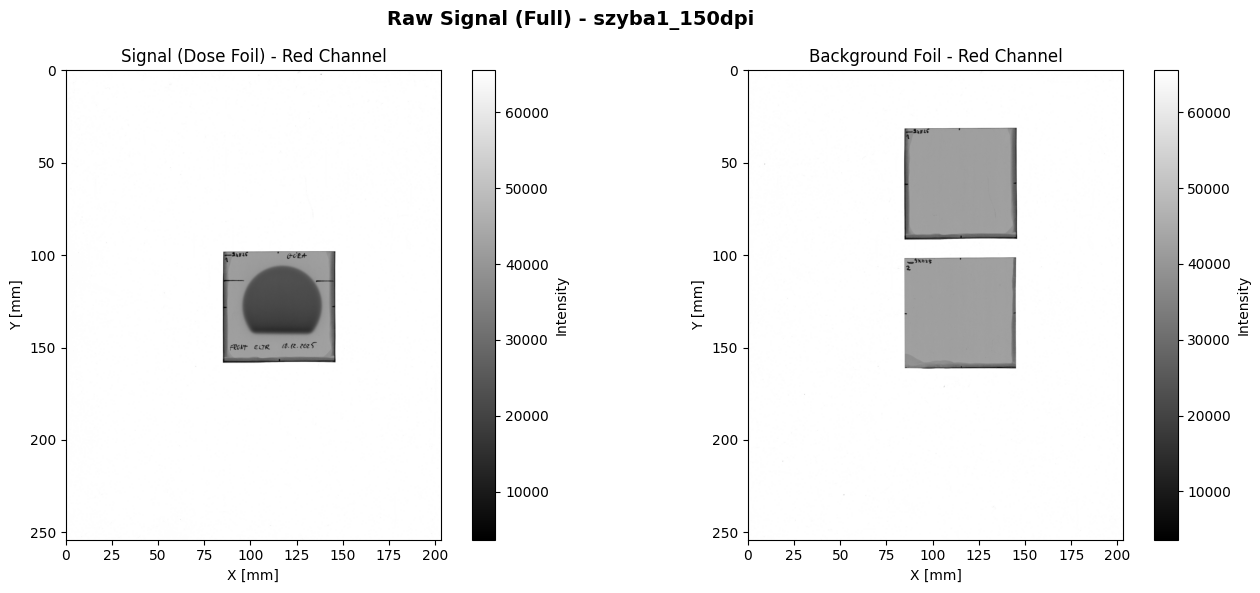

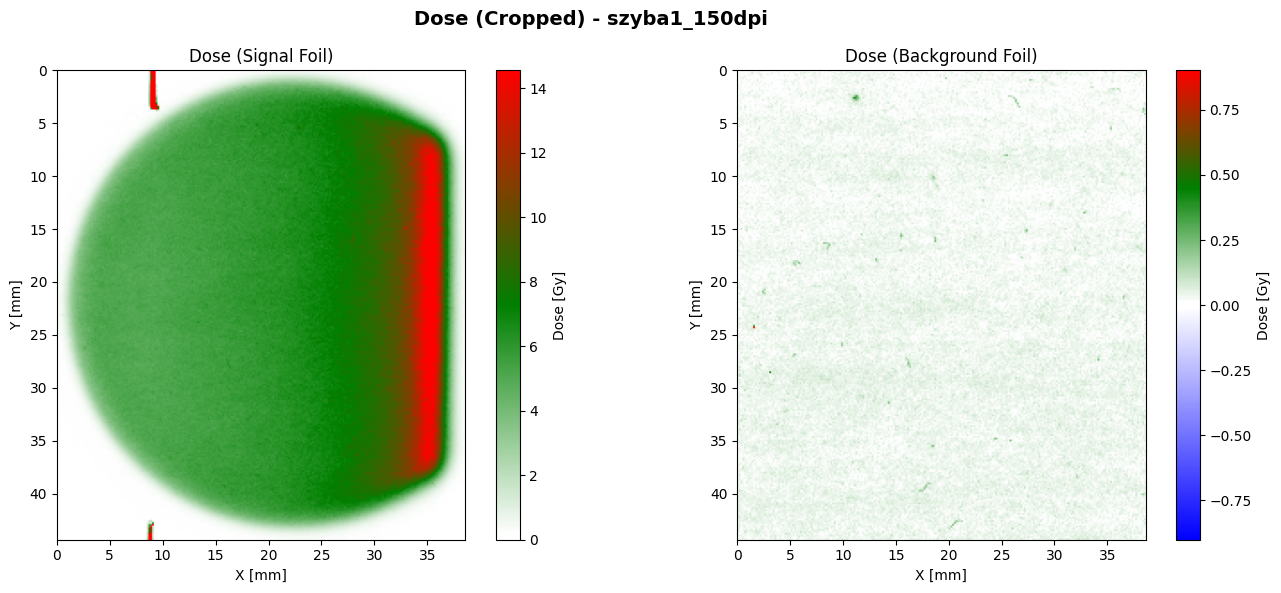

Background raw signal statistics (circle r=10.0 mm at center):
  Pixels in circle: 10953
  Mean: 42366.91
  Std:  234.40
  Std/Mean: 0.55%



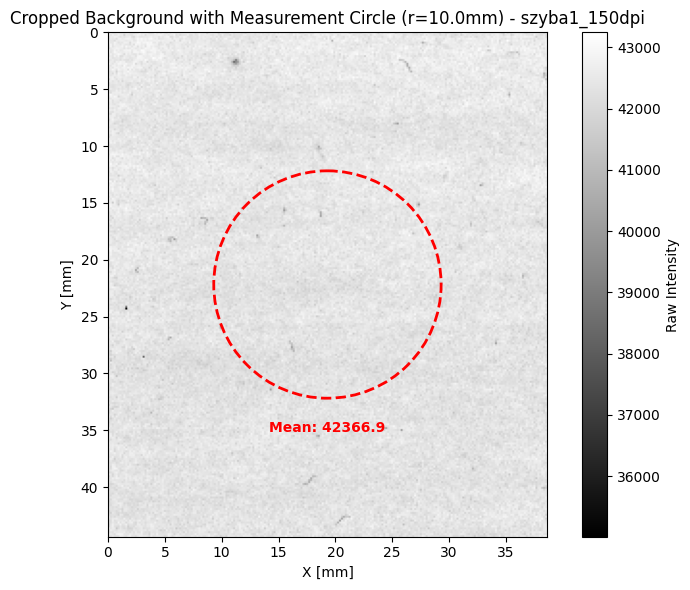


Pair: szyba1_72dpi
  Signal: gaf1_pik_Bragga_CCB_SZYBA1058.tif
  Background: gaf1-2_Sadel_20251209_SZYBA1_031.tif



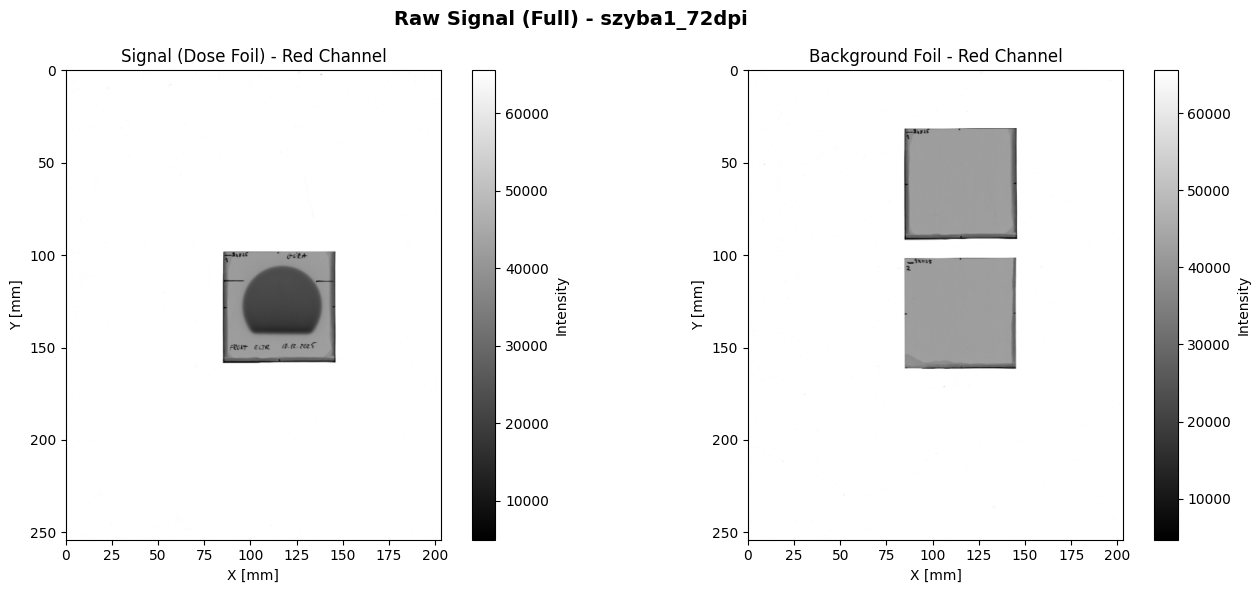

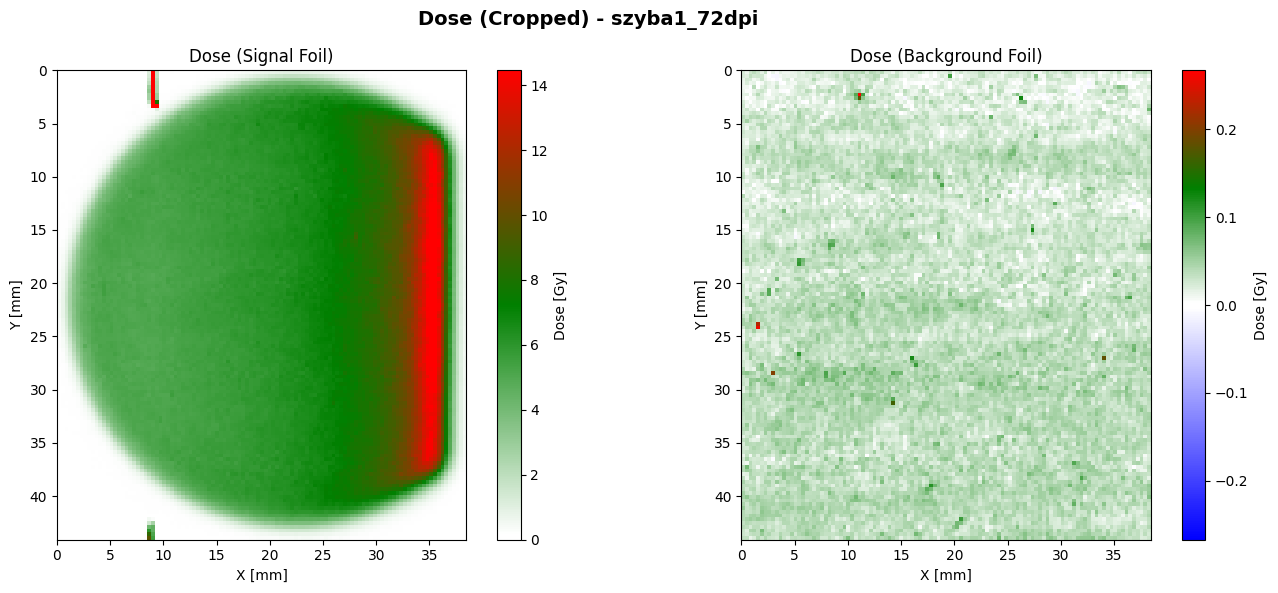

Background raw signal statistics (circle r=10.0 mm at center):
  Pixels in circle: 2537
  Mean: 42378.26
  Std:  151.41
  Std/Mean: 0.36%



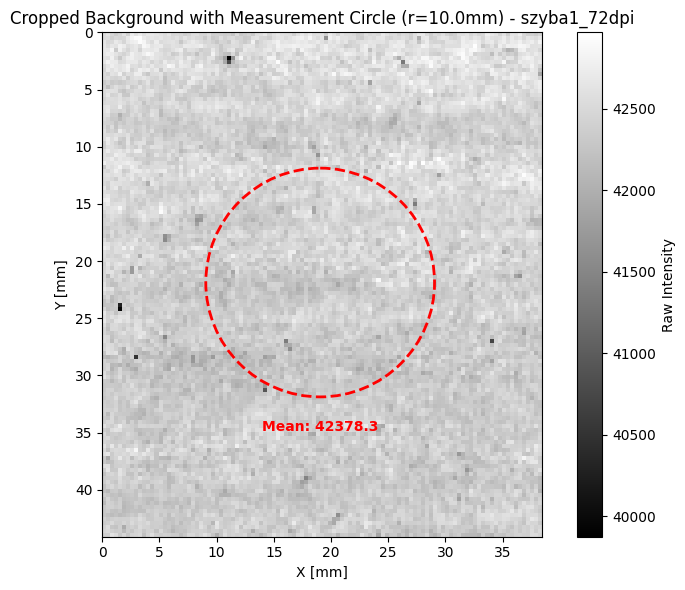


Pair: bez_szyby_150dpi
  Signal: gaf1_pik_Bragga_CCB_056.tif
  Background: gaf1-2_Sadel_20251209_029.tif



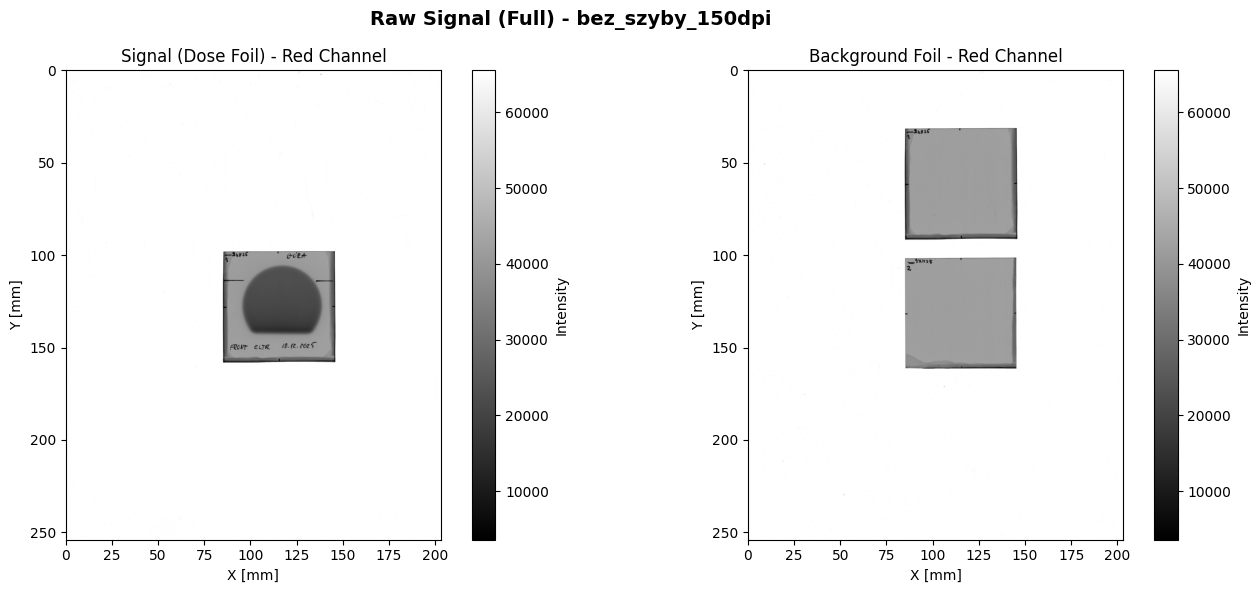

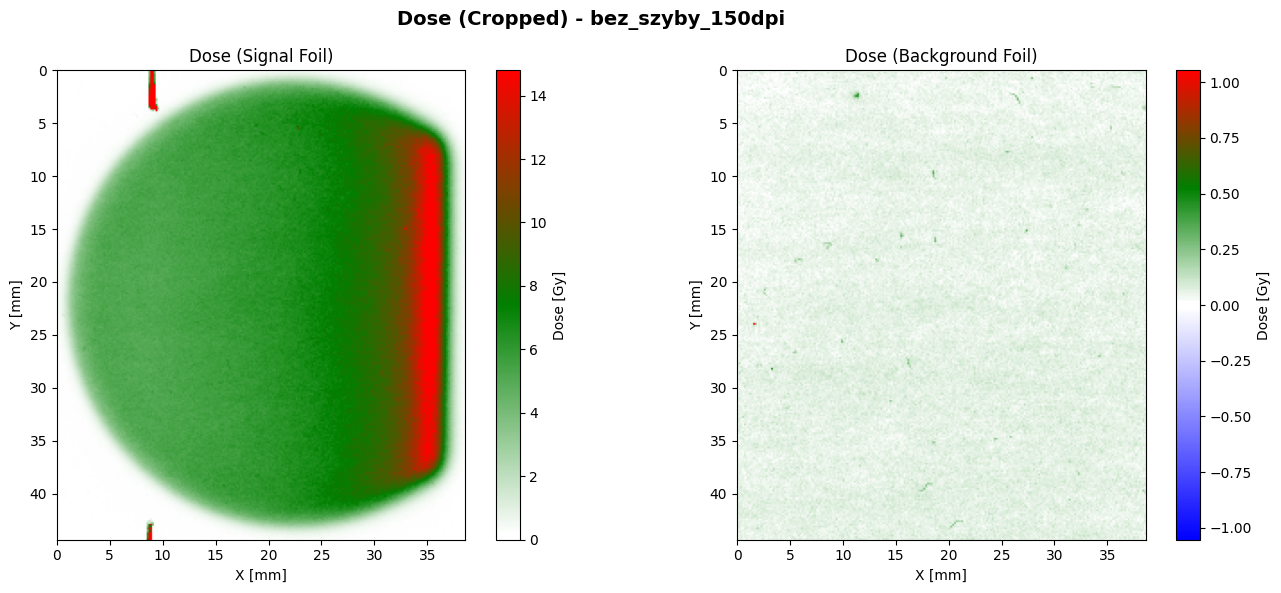

Background raw signal statistics (circle r=10.0 mm at center):
  Pixels in circle: 10953
  Mean: 42068.93
  Std:  238.98
  Std/Mean: 0.57%



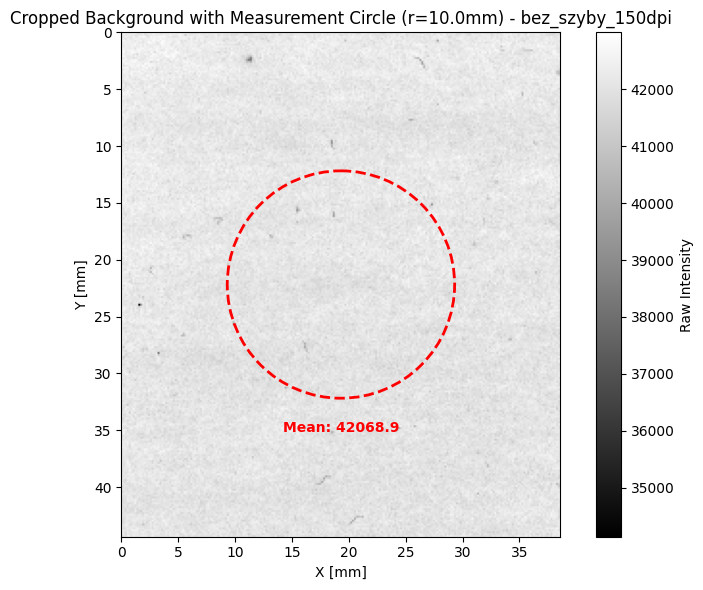

In [71]:
# Process all pairs: visualize and calculate statistics
from matplotlib.patches import Circle

CIRCLE_RADIUS_MM = 10.0

for key, pair_data in processed_pairs.items():
    print(f'\n{"="*80}')
    print(f'Pair: {key}')
    print(f'  Signal: {pair_data.signal_path.name}')
    print(f'  Background: {pair_data.background_path.name}')
    print(f'{"="*80}\n')
    
    px_to_mm = pair_data.px_to_mm
    
    # --- 1. Raw signal comparison (non-cropped) ---
    signal_red = get_red_channel(pair_data.signal_raw)
    bg_red = get_red_channel(pair_data.background_raw)
    
    fig = plot_raw_signal_comparison(
        signal_image=signal_red,
        background_image=bg_red,
        px_to_mm=px_to_mm,
        title=f'Raw Signal (Full) - {key}'
    )
    plt.show()
    
    # --- 2. Crop using signal foil's bounding box ---
    dose_cropped, bbox = auto_crop_dose(
        pair_data.dose_full,
        px_to_mm=px_to_mm,
        dose_threshold_gy=CROP_DOSE_THRESHOLD_GY,
        smooth_sigma_mm=CROP_SMOOTH_SIGMA_MM,
        min_diameter_mm=CROP_MIN_DIAMETER_MM,
        margin_mm=CROP_MARGIN_MM,
    )
    
    y_start, y_end, x_start, x_end = bbox
    
    # Crop background dose
    if pair_data.background_dose_full.shape == pair_data.dose_full.shape:
        bg_dose_cropped = pair_data.background_dose_full[y_start:y_end, x_start:x_end]
    else:
        bg_dose_cropped = pair_data.background_dose_full
    
    # Crop background raw for statistics
    if pair_data.background_raw.shape[:2] == pair_data.signal_raw.shape[:2]:
        bg_raw_cropped = bg_red[y_start:y_end, x_start:x_end]
    else:
        bg_raw_cropped = bg_red
    
    # Rotate all arrays 90 degrees anti-clockwise
    dose_cropped = rotate_dose(dose_cropped, k=1)
    bg_dose_cropped = rotate_dose(bg_dose_cropped, k=1)
    bg_raw_cropped = rotate_dose(bg_raw_cropped, k=1)
    
    # Store cropped data
    pair_data.dose_cropped = dose_cropped
    pair_data.background_dose_cropped = bg_dose_cropped
    pair_data.crop_bbox = bbox
    
    # --- 3. Dose comparison (cropped) ---
    fig = plot_dose_with_background(
        dose_array=dose_cropped,
        background_dose_array=bg_dose_cropped,
        px_to_mm=px_to_mm,
        title=f'Dose (Cropped) - {key}',
        white_threshold_percent=CMAP_WHITE_THRESHOLD_PERCENT
    )
    plt.show()
    
    # --- 4. Calculate statistics from circular region in background ---
    height, width = bg_raw_cropped.shape
    center_y, center_x = height // 2, width // 2
    
    # Create circular mask
    radius_px = CIRCLE_RADIUS_MM / px_to_mm
    y_coords, x_coords = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((y_coords - center_y)**2 + (x_coords - center_x)**2)
    circular_mask = dist_from_center <= radius_px
    
    # Extract values within circle
    bg_values_in_circle = bg_raw_cropped[circular_mask]
    
    # Calculate statistics
    mean_val = np.mean(bg_values_in_circle)
    std_val = np.std(bg_values_in_circle)
    std_percent = (std_val / mean_val) * 100 if mean_val != 0 else 0
    
    print(f'Background raw signal statistics (circle r={CIRCLE_RADIUS_MM:.1f} mm at center):')
    print(f'  Pixels in circle: {np.sum(circular_mask)}')
    print(f'  Mean: {mean_val:.2f}')
    print(f'  Std:  {std_val:.2f}')
    print(f'  Std/Mean: {std_percent:.2f}%')
    print()
    
    # --- 5. Show cropped background with measurement circle ---
    fig, ax = plt.subplots(figsize=(8, 6))
    extent_bg = [0, width * px_to_mm, height * px_to_mm, 0]
    im = ax.imshow(bg_raw_cropped, cmap='gray', extent=extent_bg, aspect='equal')
    
    # Add circle to show where background was measured
    circle = Circle(
        (center_x * px_to_mm, center_y * px_to_mm),
        CIRCLE_RADIUS_MM,
        fill=False, color='red', linewidth=2, linestyle='--'
    )
    ax.add_patch(circle)
    
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')
    ax.set_title(f'Cropped Background with Measurement Circle (r={CIRCLE_RADIUS_MM:.1f}mm) - {key}')
    plt.colorbar(im, ax=ax, label='Raw Intensity', fraction=0.046)
    
    # Add annotation with mean value
    ax.text(
        center_x * px_to_mm, center_y * px_to_mm + CIRCLE_RADIUS_MM + 2,
        f'Mean: {mean_val:.1f}',
        ha='center', va='top', fontsize=10, color='red', fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()

## Recalibration using Background Mean from Each Pair

In [72]:
# Recalculate dose using pair-specific background from circular region
from ebt.dosimetry import DEFAULT_BG_G, DEFAULT_BG_B

for key, pair_data in processed_pairs.items():
    print(f'\n{"="*80}')
    print(f'Recalibrating pair: {key}')
    print(f'{"="*80}\n')
    
    px_to_mm = pair_data.px_to_mm
    
    # Get background raw red channel
    bg_red = get_red_channel(pair_data.background_raw)
    
    # Get crop bbox from signal
    dose_cropped_temp, bbox = auto_crop_dose(
        pair_data.dose_full,
        px_to_mm=px_to_mm,
        dose_threshold_gy=CROP_DOSE_THRESHOLD_GY,
        smooth_sigma_mm=CROP_SMOOTH_SIGMA_MM,
        min_diameter_mm=CROP_MIN_DIAMETER_MM,
        margin_mm=CROP_MARGIN_MM,
    )
    
    y_start, y_end, x_start, x_end = bbox
    
    # Crop background raw
    if pair_data.background_raw.shape[:2] == pair_data.signal_raw.shape[:2]:
        bg_raw_cropped = bg_red[y_start:y_end, x_start:x_end]
    else:
        bg_raw_cropped = bg_red
    
    # Rotate
    bg_raw_cropped = rotate_dose(bg_raw_cropped, k=1)
    
    # Calculate mean from circular region at center
    height, width = bg_raw_cropped.shape
    center_y, center_x = height // 2, width // 2
    
    radius_px = CIRCLE_RADIUS_MM / px_to_mm
    y_coords, x_coords = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((y_coords - center_y)**2 + (x_coords - center_x)**2)
    circular_mask = dist_from_center <= radius_px
    
    # Get mean background value from circle
    bg_mean_from_circle = np.mean(bg_raw_cropped[circular_mask])
    
    print(f'Background mean (r={CIRCLE_RADIUS_MM:.1f}mm circle): {bg_mean_from_circle:.2f}')
    print(f'Default background: {42804.451:.2f}')
    print(f'Difference: {bg_mean_from_circle - 42804.451:.2f} ({(bg_mean_from_circle/42804.451 - 1)*100:.2f}%)')
    
    # Store background mean and circular mask info in pair_data
    pair_data.bg_mean_from_circle = bg_mean_from_circle
    pair_data.bg_raw_cropped_for_stats = bg_raw_cropped
    pair_data.circular_mask = circular_mask
    pair_data.circle_center = (center_y, center_x)
    pair_data.circle_radius_px = radius_px
    
    # Recalculate dose with pair-specific background
    # Use the background mean from the circle as the red channel background
    new_bg_values = (bg_mean_from_circle, DEFAULT_BG_G, DEFAULT_BG_B)
    
    # Recalculate dose for signal
    dose_recalibrated = ebt3_dose_Gy(pair_data.signal_raw, bg_values=new_bg_values)
    
    # Crop and rotate the recalibrated dose
    dose_recal_cropped = dose_recalibrated[y_start:y_end, x_start:x_end]
    dose_recal_cropped = rotate_dose(dose_recal_cropped, k=1)
    
    # Report dose range from cropped area only
    print(f'Original dose range (cropped): [{pair_data.dose_cropped.min():.2f}, {pair_data.dose_cropped.max():.2f}] Gy')
    print(f'Recalibrated dose range (cropped): [{dose_recal_cropped.min():.2f}, {dose_recal_cropped.max():.2f}] Gy')
    
    # Store recalibrated data
    pair_data.dose_recalibrated_full = dose_recalibrated
    pair_data.dose_recalibrated_cropped = dose_recal_cropped

print(f'\n{"="*80}')
print('Recalibration complete for all pairs')
print(f'{"="*80}')


Recalibrating pair: szyba1_150dpi

Background mean (r=10.0mm circle): 42366.91
Default background: 42804.45
Difference: -437.54 (-1.02%)
Original dose range (cropped): [0.02, 63.97] Gy
Recalibrated dose range (cropped): [-0.01, 63.11] Gy

Recalibrating pair: szyba1_72dpi

Background mean (r=10.0mm circle): 42378.26
Default background: 42804.45
Difference: -426.20 (-1.00%)
Original dose range (cropped): [0.04, 66.78] Gy
Recalibrated dose range (cropped): [0.00, 65.91] Gy

Recalibrating pair: bez_szyby_150dpi

Background mean (r=10.0mm circle): 42068.93
Default background: 42804.45
Difference: -735.52 (-1.72%)
Original dose range (cropped): [0.04, 71.77] Gy
Recalibrated dose range (cropped): [-0.02, 70.20] Gy

Recalibration complete for all pairs


## Visualize Recalibrated Dose with Profiles


Visualizing recalibrated dose: szyba1_150dpi
  Background mean used: 42366.91



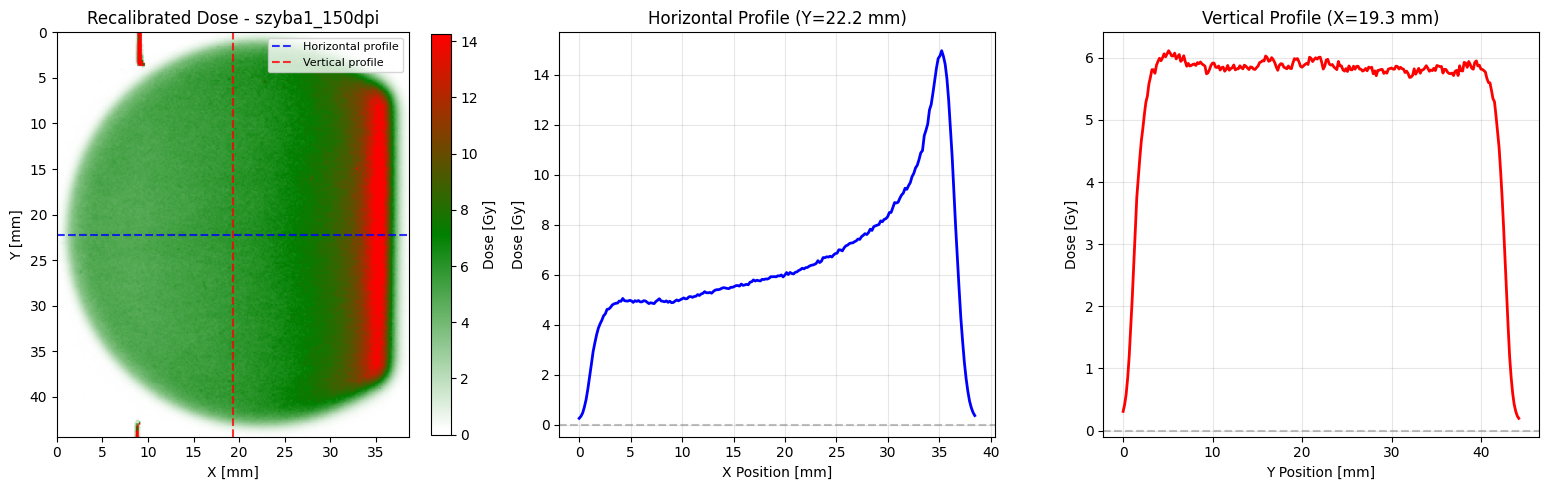


Visualizing recalibrated dose: szyba1_72dpi
  Background mean used: 42378.26



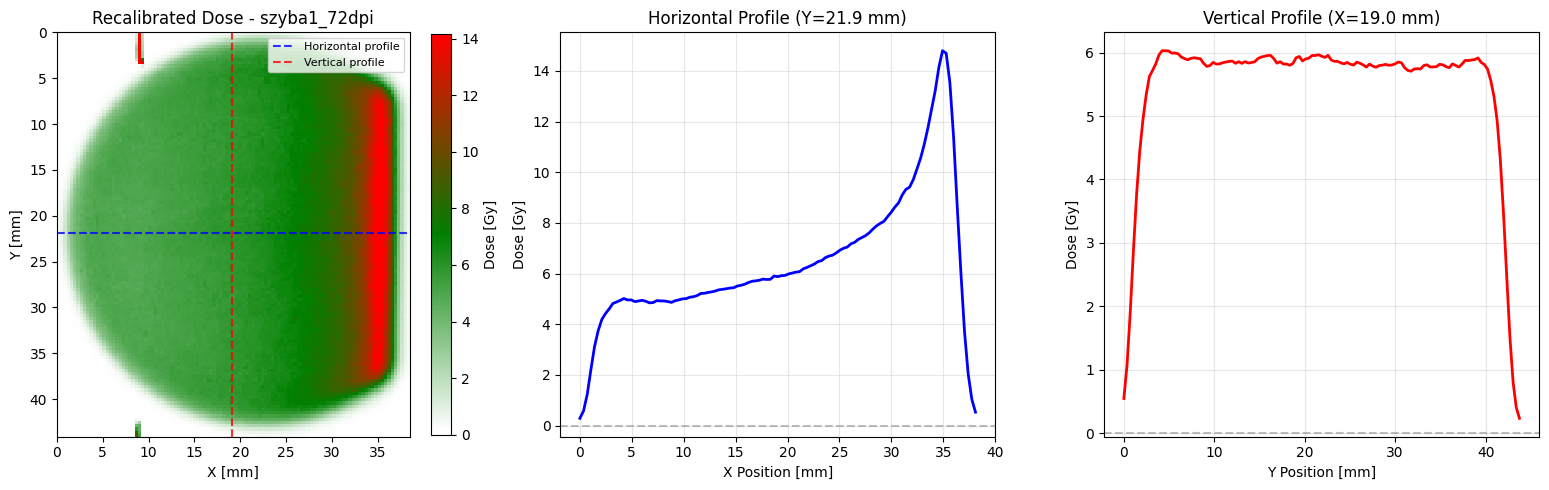


Visualizing recalibrated dose: bez_szyby_150dpi
  Background mean used: 42068.93



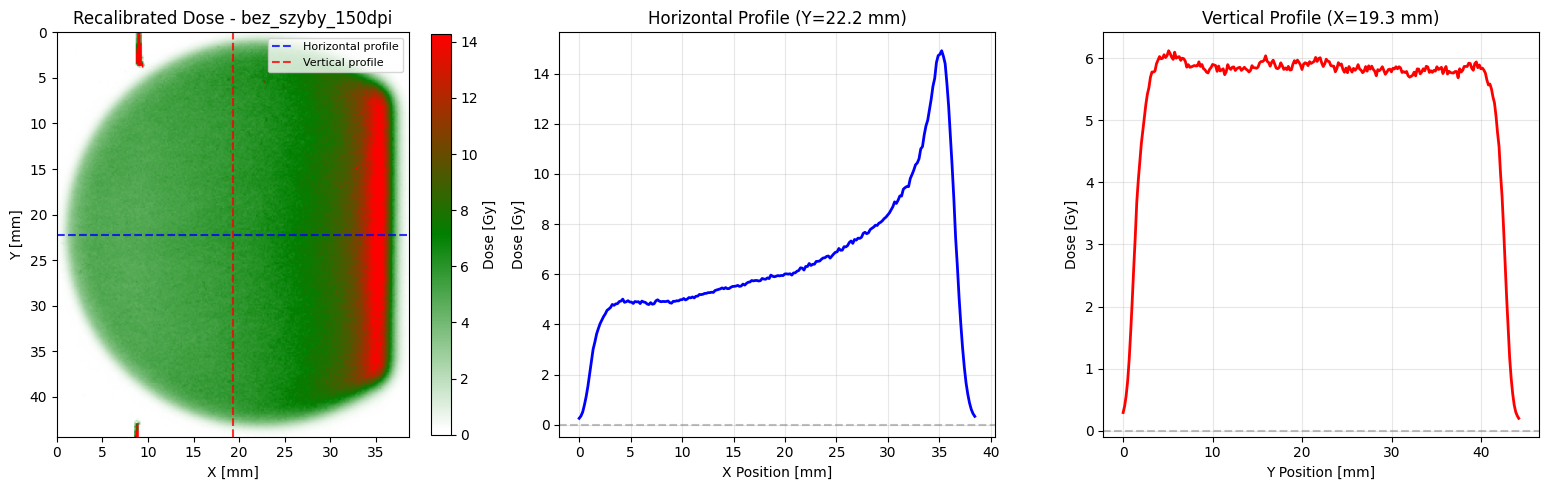

In [73]:
# Visualize recalibrated dose with 2D map and profiles for each pair

for key, pair_data in processed_pairs.items():
    print(f'\n{"="*80}')
    print(f'Visualizing recalibrated dose: {key}')
    print(f'  Background mean used: {pair_data.bg_mean_from_circle:.2f}')
    print(f'{"="*80}\n')
    
    px_to_mm = pair_data.px_to_mm
    dose_cropped = pair_data.dose_recalibrated_cropped
    height, width = dose_cropped.shape
    
    # Plot 2D dose map with profiles
    vmax = np.percentile(dose_cropped[dose_cropped > 0], 99) if (dose_cropped > 0).any() else dose_cropped.max()
    cmap = create_dose_colormap(CMAP_WHITE_THRESHOLD_PERCENT)
    
    fig = plt.figure(figsize=(16, 5))
    
    # 2D dose plot
    ax1 = plt.subplot(1, 3, 1)
    extent = [0, width * px_to_mm, height * px_to_mm, 0]
    im = ax1.imshow(dose_cropped, cmap=cmap, vmin=0, vmax=vmax, 
                    extent=extent, aspect='equal')
    ax1.set_xlabel('X [mm]')
    ax1.set_ylabel('Y [mm]')
    ax1.set_title(f'Recalibrated Dose - {key}')
    plt.colorbar(im, ax=ax1, label='Dose [Gy]', fraction=0.046)
    
    # Profile positions at center
    y_pos = height // 2
    x_pos = width // 2
    y_pos_mm = y_pos * px_to_mm
    x_pos_mm = x_pos * px_to_mm
    
    # Add profile position lines on 2D dose plot
    ax1.axhline(y=y_pos_mm, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label='Horizontal profile')
    ax1.axvline(x=x_pos_mm, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Vertical profile')
    ax1.legend(loc='upper right', fontsize=8)
    
    # Half-width for averaging
    hw = 10
    
    # Horizontal profile
    ax2 = plt.subplot(1, 3, 2)
    h_profile = dose_cropped[max(0, y_pos-hw):min(height, y_pos+hw), :].mean(axis=0)
    h_x_mm = np.arange(len(h_profile)) * px_to_mm
    ax2.plot(h_x_mm, h_profile, 'b-', linewidth=2)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('X Position [mm]')
    ax2.set_ylabel('Dose [Gy]')
    ax2.set_title(f'Horizontal Profile (Y={y_pos_mm:.1f} mm)')
    ax2.grid(True, alpha=0.3)
    
    # Vertical profile
    ax3 = plt.subplot(1, 3, 3)
    v_profile = dose_cropped[:, max(0, x_pos-hw):min(width, x_pos+hw)].mean(axis=1)
    v_y_mm = np.arange(len(v_profile)) * px_to_mm
    ax3.plot(v_y_mm, v_profile, 'r-', linewidth=2)
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Y Position [mm]')
    ax3.set_ylabel('Dose [Gy]')
    ax3.set_title(f'Vertical Profile (X={x_pos_mm:.1f} mm)')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

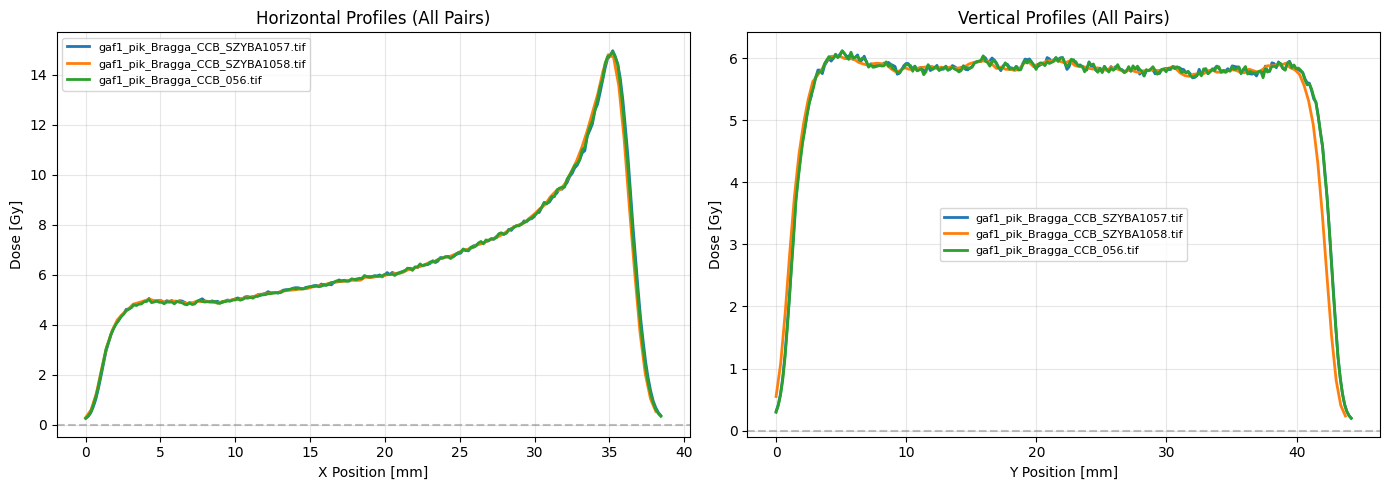

In [74]:
# Combine all profiles on single plots
fig, (ax_h, ax_v) = plt.subplots(1, 2, figsize=(14, 5))

hw = 10  # Half-width for averaging

for key, pair_data in processed_pairs.items():
    px_to_mm = pair_data.px_to_mm
    dose_cropped = pair_data.dose_recalibrated_cropped
    height, width = dose_cropped.shape
    
    # Profile positions at center
    y_pos = height // 2
    x_pos = width // 2
    
    # Horizontal profile
    h_profile = dose_cropped[max(0, y_pos-hw):min(height, y_pos+hw), :].mean(axis=0)
    h_x_mm = np.arange(len(h_profile)) * px_to_mm
    
    # Vertical profile
    v_profile = dose_cropped[:, max(0, x_pos-hw):min(width, x_pos+hw)].mean(axis=1)
    v_y_mm = np.arange(len(v_profile)) * px_to_mm
    
    # Use signal filename as label
    label = pair_data.signal_path.name
    
    ax_h.plot(h_x_mm, h_profile, linewidth=2, label=label)
    ax_v.plot(v_y_mm, v_profile, linewidth=2, label=label)

# Horizontal profiles plot
ax_h.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax_h.set_xlabel('X Position [mm]')
ax_h.set_ylabel('Dose [Gy]')
ax_h.set_title('Horizontal Profiles (All Pairs)')
ax_h.grid(True, alpha=0.3)
ax_h.legend(loc='best', fontsize=8)

# Vertical profiles plot
ax_v.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax_v.set_xlabel('Y Position [mm]')
ax_v.set_ylabel('Dose [Gy]')
ax_v.set_title('Vertical Profiles (All Pairs)')
ax_v.grid(True, alpha=0.3)
ax_v.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()